<a href="https://colab.research.google.com/github/gnaveenpaul123-cyber/pro_2/blob/main/Project_LAPD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:

dataset_url = 'https://raw.githubusercontent.com/gnaveenpaul123-cyber/pro_2/refs/heads/main/LAPD_NIBRS_Offenses_Dataset_2026_to_Present.csv'
df = pd.read_csv(dataset_url)

print("Dataset loaded successfully from GitHub!")

Dataset loaded successfully from GitHub!


In [29]:
# checking basic info of data set
df.shape
#It has 28591 rows and 31 columns

(28591, 31)

In [30]:
df.info()
#total 31 columns float-2, int-6, object- 23.
#it is showing nulls in the data set
# Date Rptd, Date OCC are in object data types but those supposed to be in datetime and Time OCC in int and this supposed to be in datetime
df.isnull().sum()
#Null values present in dataset: - Group-	989, Crime Against	- 16, Premise Cd	- 628, Weapon Used Cd -	20438, Weapon Desc -	20438, LAT and LON - 1.
#Weapon Used Cd -	20438, Weapon Desc -	20438  these two could be no weapons used.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28591 entries, 0 to 28590
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CaseNo                   28591 non-null  object 
 1   UniqueNIBRNo             28591 non-null  object 
 2   Date Rptd                28591 non-null  object 
 3   Date OCC                 28591 non-null  object 
 4   Time OCC                 28591 non-null  int64  
 5   AREA                     28591 non-null  int64  
 6   AREA NAME                28591 non-null  object 
 7   RPT Dist No              28591 non-null  int64  
 8   TotalOffenseCount        28591 non-null  int64  
 9   Group                    27602 non-null  object 
 10  NIBR Code                28591 non-null  object 
 11  NIBR Description         28591 non-null  object 
 12  Crime Against            28575 non-null  object 
 13  Premise Cd               27963 non-null  object 
 14  Premise Desc          

,0
CaseNo,0
UniqueNIBRNo,0
Date Rptd,0
Date OCC,0
Time OCC,0
AREA,0
AREA NAME,0
RPT Dist No,0
TotalOffenseCount,0
Group,989


In [31]:
df.duplicated().sum()
#There is no duplicates

np.int64(0)

In [32]:
#Changed Date rptd, Date OCC from object to datetime
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], errors = 'coerce')
df['Date OCC'] = pd.to_datetime(df['Date OCC'], errors = 'coerce')

In [33]:
#'Time OCC' is in Int form so we need to change it into 'str' in order to do the concating lateron.
df['Time OCC'] = df['Time OCC'].astype(str)

In [34]:
#I am creating a custom function in order to add '0' infront of the 'Time OCC' when certain conditions met.
#by doing so we can get that data into our required format in order to caluclation
def pad_time_custom(time_str):
  time_str = str(time_str) # Ensure it's a string
  if len(time_str) == 3:
    return '0' + time_str  #if len(time_str) == 3 adding '0'  infront
  elif len(time_str) == 2:
    return '00' + time_str#if len(time_str) == 2 adding '00'  infront
  elif len(time_str) == 1:
    return '000' + time_str#if len(time_str) == 1 adding '000'  infront
  else:
    return time_str

In [35]:
#since 'Time OCC' has time formats like '57', '300', '5' we should change these to '0057', '0300', '0005'.
#we have applied the custom function on 'Time OCC'
df['Time OCC'] = df['Time OCC'].apply(pad_time_custom)
print("Time OCC column after applying custom padding function:")
print(df[['Time OCC']].head())

Time OCC column after applying custom padding function:
  Time OCC
0     0250
1     0300
2     0300
3     0240
4     0300


In [36]:
#so from the dataset we have two columns having half of the info same.
#'Time OCC', 'Date OCC' has time same.
# so we extract y-m-d and add it to 'Time OCC' getting the row in (%Y-%m-%d %H-%M) format
df['Year_date'] = df['Date OCC'].dt.strftime('%Y-%m-%d') # type casting datetime into str
df['Year_time'] = df['Year_date']+' '+df['Time OCC'] # concatinating two columns
df['Full_OCC_Datetime'] = pd.to_datetime(df['Year_time'],format='%Y-%m-%d %H%M', errors = 'coerce')
#then again changing the column to datetime
print("First 5 rows of 'Full_OCC_Datetime':")
print(df['Full_OCC_Datetime'].head()) # firsst five
print(f"Data type of 'Full_OCC_Datetime': {df['Full_OCC_Datetime'].dtype}") # checking the datatype

First 5 rows of 'Full_OCC_Datetime':
0   2026-01-01 02:50:00
1   2026-01-01 03:00:00
2   2026-01-01 03:00:00
3   2026-01-01 02:40:00
4   2026-01-01 03:00:00
Name: Full_OCC_Datetime, dtype: datetime64[ns]
Data type of 'Full_OCC_Datetime': datetime64[ns]


In [37]:
#dropping the unwanted columns inorder to make data more efficient
df.drop(['Year_date','Year_time'],axis = 1, inplace = True)

In [38]:
df.isnull().sum()

,0
CaseNo,0
UniqueNIBRNo,0
Date Rptd,0
Date OCC,0
Time OCC,0
AREA,0
AREA NAME,0
RPT Dist No,0
TotalOffenseCount,0
Group,989


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28591 entries, 0 to 28590
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   CaseNo                   28591 non-null  object        
 1   UniqueNIBRNo             28591 non-null  object        
 2   Date Rptd                28591 non-null  datetime64[ns]
 3   Date OCC                 28591 non-null  datetime64[ns]
 4   Time OCC                 28591 non-null  object        
 5   AREA                     28591 non-null  int64         
 6   AREA NAME                28591 non-null  object        
 7   RPT Dist No              28591 non-null  int64         
 8   TotalOffenseCount        28591 non-null  int64         
 9   Group                    27602 non-null  object        
 10  NIBR Code                28591 non-null  object        
 11  NIBR Description         28591 non-null  object        
 12  Crime Against            28575 n

In [40]:
#dropping null values or filling null values with 'Unknown'
df.fillna({'Weapon Used Cd':'No Weapon'},inplace = True)
print(f"Number of null values in 'Weapon Used Cd' After filling :{df['Weapon Used Cd'].isnull().sum()}")
df.fillna({'Weapon Desc':'No Weapon'},inplace = True)
print(f"Number of null values in 'Weapon Desc' After filling :{df['Weapon Desc'].isnull().sum()}")
df.fillna({'Group' : 'Unknown'}, inplace = True)
print(f"Number of null values in 'Group' After filling :{df['Group'].isnull().sum()}")
df.fillna({'Crime Against' : 'Unknown'}, inplace = True)
print(f"Number of null values in 'Crime Against' After filling :{df['Crime Against'].isnull().sum()}")

Number of null values in 'Weapon Used Cd' After filling :0
Number of null values in 'Weapon Desc' After filling :0
Number of null values in 'Group' After filling :0
Number of null values in 'Crime Against' After filling :0


In [41]:
df.dropna(subset=['LAT'], inplace=True)
print(f"Number of null values in 'LAT' after dropping: {df['LAT'].isnull().sum()}")

Number of null values in 'LAT' after dropping: 0


In [42]:
df.dropna(subset = ['LON'], inplace = True)
print(f"After dropping null from 'LON':{df['LON'].isnull().sum()}")

After dropping null from 'LON':0


In [43]:
# Premise Cd has ~2.2% missing values, which is minimal.
# Keeping as NaN to preserve data integrity.
#628 / 28591 ≈ 2.2%   ---->  If missing < 5% → safe to keep as NaN
#I do not want to change data type of premise Cd from int to obj so i am leaving it like nan
df['Premise Cd'].isnull().sum()

np.int64(628)

In [44]:
#column names are mixed of upper and lowercase. so for my easy use i am changing names into lowercase()
df.columns = df.columns.str.lower()

In [46]:
#extract day names
df['occ_day'] = df['full_occ_datetime'].dt.strftime('%A')
#extract hour from full_occ_datetime
df['occ_hour'] = df['full_occ_datetime'].dt.hour

###Visualization

/tmp/ipykernel_3775/2613882953.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_crimes.index, y=top_10_crimes.values, palette='coolwarm')


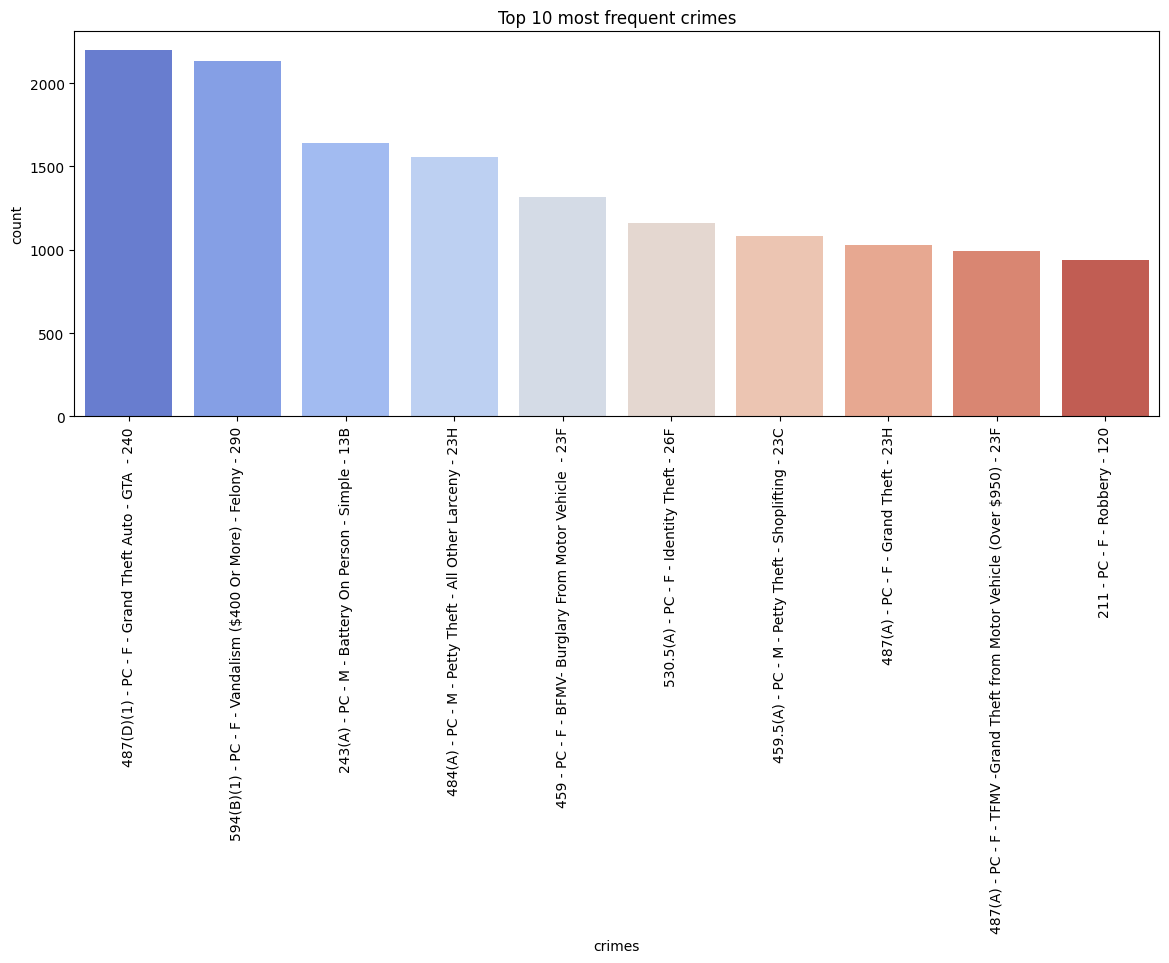

In [70]:
#Top 10 most frequent crimes
top_10_crimes = df['nibr description'].value_counts().head(10)
plt.figure(figsize=(14,5))
sns.barplot(x=top_10_crimes.index, y=top_10_crimes.values, palette='coolwarm')
plt.xticks(rotation = 90)
plt.title('Top 10 most frequent crimes')
plt.xlabel('crimes')
plt.ylabel('count')
plt.show()

## Summary:

1.  **Why was a bar chart chosen to visualize the 'Top 10 most frequent crimes'?**
    A bar chart was chosen because it effectively compares discrete categories (crime types) and their corresponding numerical values (counts), making it easy to identify the most frequent crimes and compare their occurrences.

2.  **What are the key insights observed from the `top_10_crimes` bar plot, highlighting the most prevalent crime types?**
    The plot shows a clear hierarchy of crime frequencies. The most prevalent crime is '487(D)(1) - PC - F - Grand Theft Auto - GTA - 240' with 2201 incidents, followed by '594(B)(1) - PC - F - Vandalism (\$400 Or More) - Felony - 290' with 2135 incidents, and '243(A) - PC - M - Battery On Person - Simple - 13B' with 1641 incidents.

### Data Analysis Key Findings
*   The most prevalent crime identified is '487(D)(1) - PC - F - Grand Theft Auto - GTA - 240', accounting for 2201 incidents.
*   The second most common crime is '594(B)(1) - PC - F - Vandalism (\$400 Or More) - Felony - 290', with 2135 incidents.
*   '243(A) - PC - M - Battery On Person - Simple - 13B' ranks as the third most frequent crime, with 1641 incidents.
*   There is a significant decrease in the number of incidents between the top few crimes and those lower down the list, indicating that a small number of crime types are disproportionately frequent.

### Insights or Next Steps
*   Further investigation could focus on the specific factors contributing to the high prevalence of the top three crime types to inform prevention strategies.
*   Analyzing trends over time for these most frequent crimes could reveal seasonal patterns or the impact of external events.


/tmp/ipykernel_3775/328445429.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = hour_day.index, y = hour_day.values, width = 0.5, palette = 'pastel')


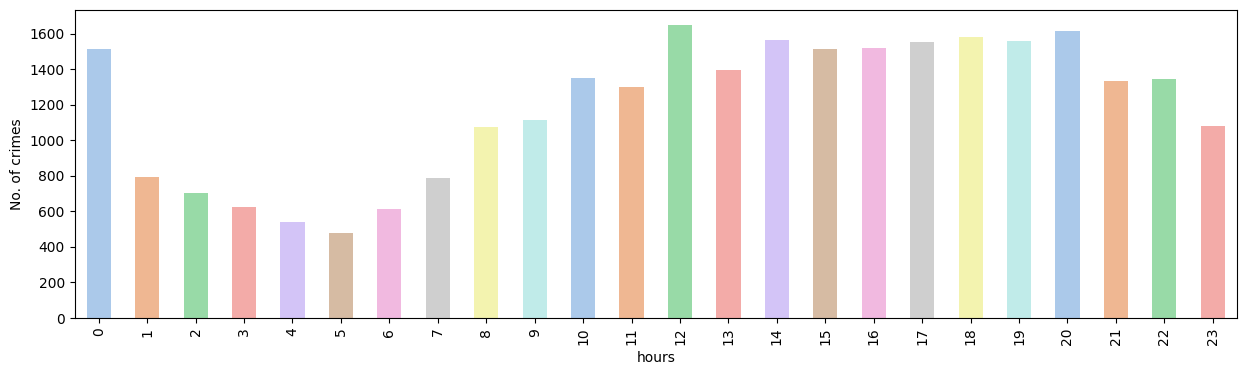

In [154]:
#Which hour of the day has highest crime?
hour_day = df.groupby('occ_hour')['occ_day'].count().sort_values(ascending = True)
plt.figure(figsize = (15,4))
sns.barplot(x = hour_day.index, y = hour_day.values, width = 0.5, palette = 'pastel')
plt.xlabel('hours')
plt.ylabel('No. of crimes')
plt.xticks(rotation = 90)
plt.show()

## Summary:

### Q&A
*   **Why was a bar chart chosen for the 'Which hour of the day has highest crime?' analysis?**
    A bar chart was selected because it is highly effective for visualizing and comparing discrete categories (the 24 hours of the day) and their corresponding numerical values (the count of crimes). Its distinct bars facilitate easy identification and comparison of crime frequencies across each hour, highlighting peaks and troughs.

### Data Analysis Key Findings
*   The early morning hours consistently show the lowest crime rates, with 5 AM having the fewest crimes (476 incidents), followed by 4 AM (542 crimes) and 6 AM (615 crimes).
*   Crime activity generally increases in the late morning and peaks in the afternoon and early evening. The hour with the highest crime count is 12 PM (1650 crimes), followed by 8 PM (1617 crimes) and 6 PM (1579 crimes).
*   Crime rates are low in the very early morning, gradually increase throughout the day, reach their highest levels in the afternoon and evening, and then start to decline late at night.

### Insights or Next Steps
*   Law enforcement resources could be strategically deployed to concentrate efforts during peak crime hours, particularly between noon and evening, to deter criminal activity.
*   Further analysis could explore the types of crimes most prevalent during peak hours versus off-peak hours to inform more targeted intervention strategies.


/tmp/ipykernel_3775/2815931787.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = day_wise_theft.index, y = day_wise_theft.values, palette = 'coolwarm')


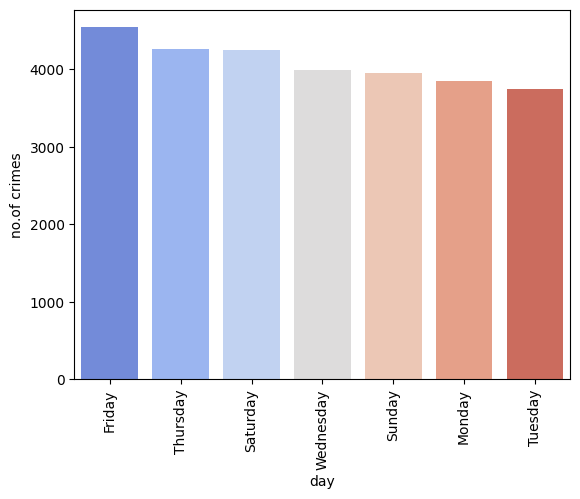

In [151]:
#Which day has highest crime?
day_wise_theft = df.groupby('occ_day')['occ_hour'].count().sort_values(ascending = False)
sns.barplot(x = day_wise_theft.index, y = day_wise_theft.values, palette = 'coolwarm')
plt.xlabel('day')
plt.ylabel('no.of crimes')
plt.xticks(rotation = 90)
plt.show()

## Summary:

A bar chart was chosen for the 'Which day has highest crime?' analysis because it is an effective visualization for comparing discrete categories (the days of the week) and their corresponding numerical values (the count of crimes). The distinct bars make it easy to quickly identify and compare crime frequencies across different days.

Key insights from the `day_wise_theft` bar plot reveal that Friday has the highest number of reported crimes with 4541 incidents. Thursday and Saturday follow with 4263 and 4252 crimes, respectively, showing a concentration of criminal activity towards the end of the week. Tuesday records the lowest number of crimes with 3741 incidents. The general trend indicates that crime rates tend to increase towards the end of the week, peaking on Friday, Thursday, and Saturday, and are lowest at the beginning of the week, particularly on Tuesday.

### Data Analysis Key Findings

*   **Visualization Choice**: A bar chart was selected for its effectiveness in comparing discrete categories (days of the week) and their corresponding numerical values (crime counts), allowing for clear visual identification of differences and rankings.
*   **Peak Crime Day**: Friday had the highest number of reported crimes, with 4541 incidents.
*   **High Crime Days**: Thursday (4263 crimes) and Saturday (4252 crimes) also showed significantly high crime rates, contributing to an overall increase in criminal activity towards the end of the week.
*   **Lowest Crime Day**: Tuesday recorded the lowest number of crimes, with 3741 incidents, making it the day with the least criminal activity.
*   **General Trend**: Crime rates exhibit an upward trend towards the end of the week, peaking around Friday, Thursday, and Saturday, and are lowest at the beginning of the week, particularly on Tuesday.

### Insights or Next Steps
*   Law enforcement could optimize resource allocation by increasing patrols and presence on Fridays, Thursdays, and Saturdays, which are identified as high-crime days.
*   Further analysis could investigate the specific types of crimes prevalent on these high-crime days to develop more targeted prevention and intervention strategies.


/tmp/ipykernel_3775/1066046739.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = total_counts.index, y = total_counts.values, palette = 'coolwarm')


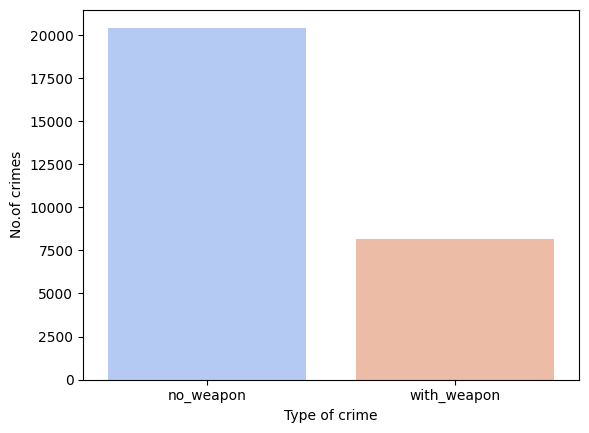

In [137]:
#Weapon Analysis
without_weapon = df.loc[df['weapon used cd'] == 'No Weapon', 'weapon used cd'].count()
with_weapon = df.loc[df['weapon used cd'] != 'No Weapon', 'weapon used cd'].count()
total_counts = pd.Series({
    'no_weapon' : without_weapon,
    'with_weapon' : with_weapon
})
sns.barplot(x = total_counts.index, y = total_counts.values, palette = 'coolwarm')
plt.xlabel('Type of crime')
plt.ylabel('No.of crimes')
plt.show()

## Summary:


*   **Why was a bar chart chosen for the weapon analysis?**
    A bar chart was chosen because it is highly effective for comparing discrete categories, such as 'crimes committed with a weapon' versus 'crimes committed without a weapon', and their corresponding numerical values. The clear separation of bars allows for a quick visual comparison of the frequency of each category.

*   **What are the key insights from the `total_counts` bar plot regarding weapon analysis?**
    The `total_counts` bar plot reveals that crimes committed without a weapon (20437) are significantly more prevalent than crimes committed with a weapon (8153).

### Data Analysis Key Findings
*   The bar chart clearly shows that crimes committed without a weapon significantly outnumber those committed with a weapon.
*   Specifically, there were 20,437 crimes reported as 'no\_weapon' compared to 8,153 crimes reported as 'with\_weapon'.

### Insights or Next Steps
*   The dataset indicates that the majority of reported crimes do not involve the use of a weapon, suggesting that non-weapon crimes represent a larger volume of incidents.
*   Further analysis could explore the nature and types of non-weapon crimes to understand their prevalence and potential prevention strategies.


/tmp/ipykernel_3775/749073721.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = area_wise_crime.index, y = area_wise_crime.values, palette = 'coolwarm')


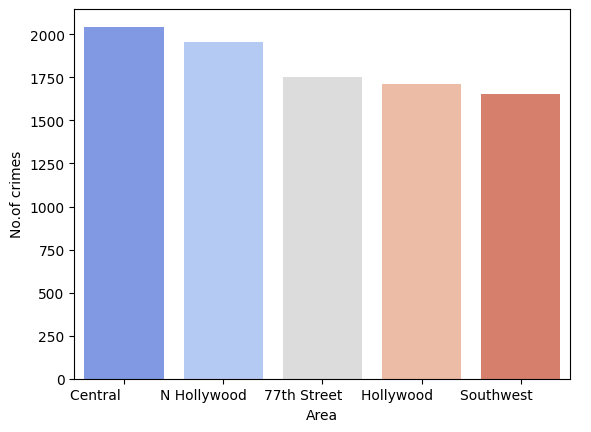

In [140]:
#Top 5 areas (or premises) where crimes happen most
area_wise_crime = df['area name'].value_counts().head(5)
sns.barplot(x = area_wise_crime.index, y = area_wise_crime.values, palette = 'coolwarm')
plt.xlabel('Area')
plt.ylabel('No.of crimes')
plt.show()

### Summary of Area-wise Crime Analysis

#### why i choose Bar Chart:
A bar chart was chosen to visualize the top 5 crime areas because it is ideal for comparing discrete categories (different geographic areas) and their corresponding numerical values (crime counts). Its clear, distinct bars make it easy to quickly identify and rank the areas with the highest crime frequencies.

#### Insights from the `area_wise_crime` Bar Plot:
Based on the `area_wise_crime` bar plot, the areas with the highest crime occurrences are:

1.  **Central**
2.  **N Hollywood**
3.  **77th Street**
4.  **Hollywood**
5.  **Southwest**

These areas consistently show the highest number of reported crimes, suggesting they are critical zones for resource allocation and crime prevention efforts.


### Data Analysis Key Findings
*   A bar chart was chosen for visualizing the top 5 crime areas due to its effectiveness in comparing discrete categories (geographic areas) and their corresponding numerical values (crime counts).
*   The top 5 areas with the highest crime occurrences were identified as: **Central, N Hollywood, 77th Street, Hollywood, and Southwest**.

### Insights or Next Steps
*   These identified high-crime areas should be prioritized for resource allocation and targeted crime prevention strategies.
*   Further investigation into the specific types of crimes prevalent in each of these top areas could provide more actionable insights for tailored interventions.


In [147]:
#pivot table
crime_by_day_hour = pivot = df.pivot_table(index='occ_day', columns='occ_hour', aggfunc='size')
print("Crime frequency pivot table created:")
print(crime_by_day_hour.head())

Crime frequency pivot table created:
occ_hour   0    1    2    3    4   5    6    7    8    9   ...   14   15   16  \
occ_day                                                    ...                  
Friday    217   76   87   84   79  74   91  144  151  188  ...  230  256  249   
Monday    217  104  111   77   61  70  101  104  143  146  ...  234  187  182   
Saturday  254  125  135  101   76  59  102  100  150  160  ...  215  220  211   
Sunday    261  149  131  123  108  74   77   83  135  128  ...  214  187  205   
Thursday  211  119   83   79   84  83   90  123  180  160  ...  218  234  251   

occ_hour   17   18   19   20   21   22   23  
occ_day                                      
Friday    272  268  275  266  221  213  221  
Monday    212  212  204  212  177  159  138  
Saturday  198  257  202  249  214  230  197  
Sunday    197  190  199  237  212  211  132  
Thursday  228  225  234  271  175  215  147  

[5 rows x 24 columns]


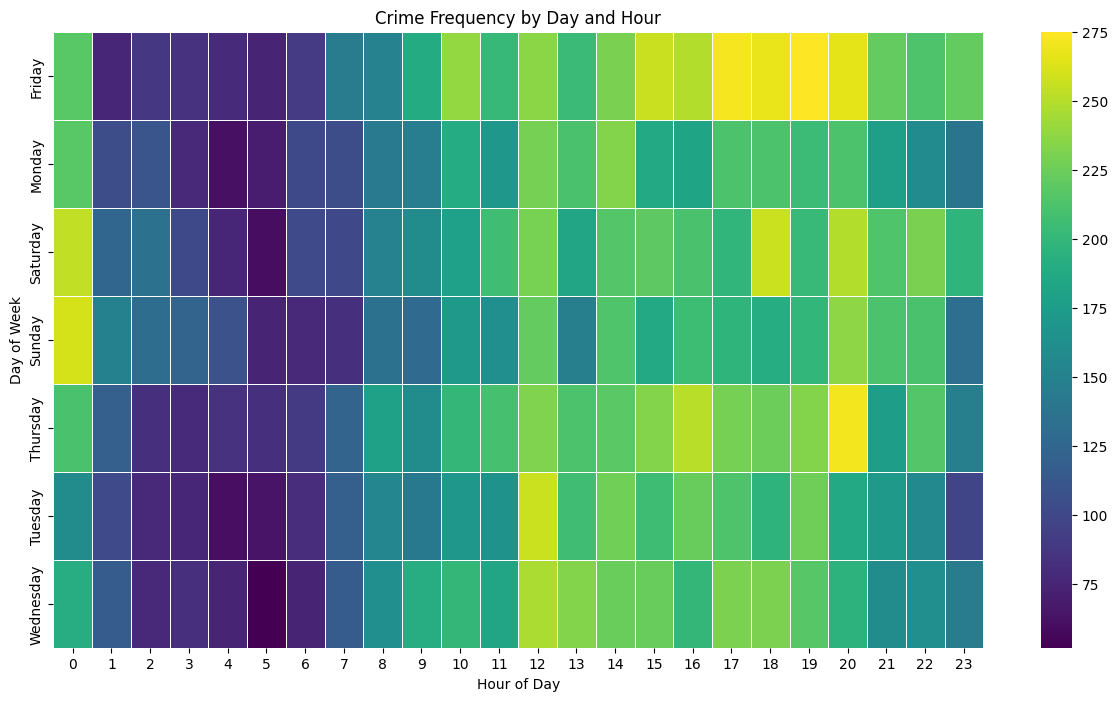

In [148]:
plt.figure(figsize=(15, 8))
sns.heatmap(crime_by_day_hour, cmap='viridis', annot=False, fmt='.0f', linewidths=.5)
plt.title('Crime Frequency by Day and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

### Summary of Crime Frequency by Day and Hour


*   **Peak Crime Hours**: Crimes appear to be more frequent during  generally between 4 PM (16:00) and 9 PM (21:00).
*   **Lowest Crime Hours**: The early morning hours, consistently show the lowest crime rates.
*   **Day-wise Distribution**:
    *   **Friday** and **Thursday** seem to have higher overall crime counts compared to other days
    *   **Saturday** also exhibits high crime activity.
    *   **Sunday**, **Monday**, and **Tuesday** tend to have relatively lower crime rates across the day compared to the end of the week.

In conclusion, the data suggests that crime activity in Los Angeles peaks during the afternoon and evening, with the highest frequencies observed towards the end of the week, particularly on Fridays and Thursdays.


### Data Analysis Key Findings

*   Crimes are most frequent during late afternoon and evening hours, specifically between 4 PM (16:00) and 9 PM (21:00).
*   The lowest crime rates consistently occur in the early morning hours, particularly between 2 AM (02:00) and 5 AM (05:00).
*   Friday and Thursday exhibit higher overall crime counts compared to other days, especially during peak hours. This finding aligns with a previous `day_wise_theft` analysis.
*   Saturday also shows significant crime activity, predominantly in the afternoon and evening.
*   Sunday, Monday, and Tuesday generally have relatively lower crime rates throughout the day compared to the end of the week.
*   Specific crime hotspots are observable on Friday and Thursday evenings, indicating these as particularly vulnerable times.

### Insights or Next Steps

*   Law enforcement resources could be  allocated to increase presence and patrols during (16:00-21:00), especially on Thursdays and Fridays, to deter criminal activity.


In [149]:
df['occ_date'] = df['full_occ_datetime'].dt.date
crimes_by_date = df.groupby('occ_date').size()

print("Crimes grouped by date (first 5 entries):")
print(crimes_by_date.head())
print(f"\nTotal unique dates with crimes: {len(crimes_by_date)}")

Crimes grouped by date (first 5 entries):
occ_date
2000-11-30    1
2003-09-26    1
2004-08-14    1
2004-10-11    1
2006-01-01    1
dtype: int64

Total unique dates with crimes: 608


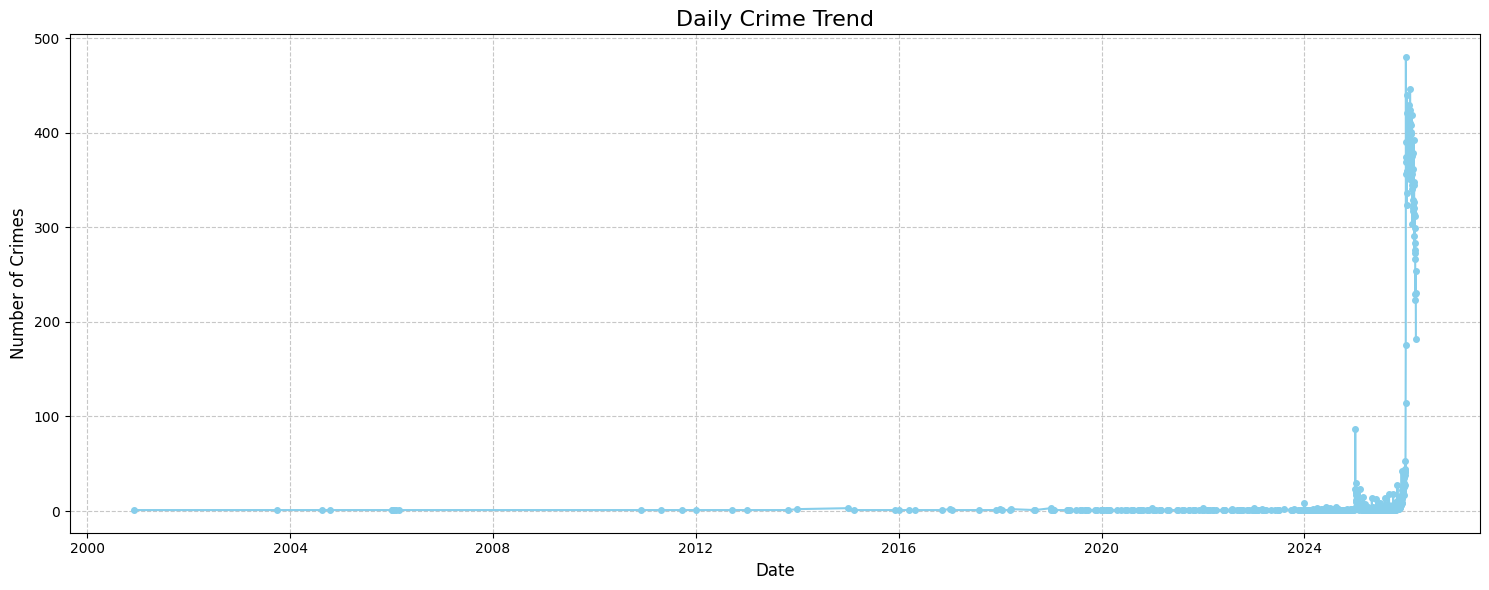

In [150]:
plt.figure(figsize=(15, 6))
crimes_by_date.plot(kind='line', marker='o', linestyle='-', color='skyblue', markersize=4)
plt.title('Daily Crime Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### Summary of Daily Crime Trends

The line chart displays the daily crime occurrences over the observed period. From this visualization, the following trends can be identified:

*   **Fluctuations over time**: The number of crimes per day shows significant fluctuations, indicating that crime activity is not constant and varies daily.
*   **seasonality/cyclical patterns**: The peaks suggest potential patterns, possibly weekly or monthly variations.


## Summary:

### Data Analysis Key Findings
*   The crime data was successfully grouped by the date component of the `full_occ_datetime` column.
*   A total of 608 unique dates recorded crime occurrences.
*   No distinct long-term trend (e.g., increasing or decreasing) was identified from the observed period.
*   Specific spikes were observed on certain days, indicating instances of unusually high crime activity.

### Insights or Next Steps
*   Investigate potential seasonality (e.g., weekly or monthly cycles) in crime occurrences to identify recurring patterns and peak crime periods.
.
